<a href="https://colab.research.google.com/github/headdown0845/2026_First-semester/blob/main/260529_2355022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sympy import symbols
x, y = symbols('x y')
expr = x + 2*y

In [ ]:
from sympy import diff, integrate
expr = x**2 + 3*x + 2
derivative = diff(expr, x)
integral = integrate(expr, x)

In [ ]:
from sympy import Eq, solve
eq = Eq(x**2 + 2*x + 1, 0)
sol = solve(eq, x)

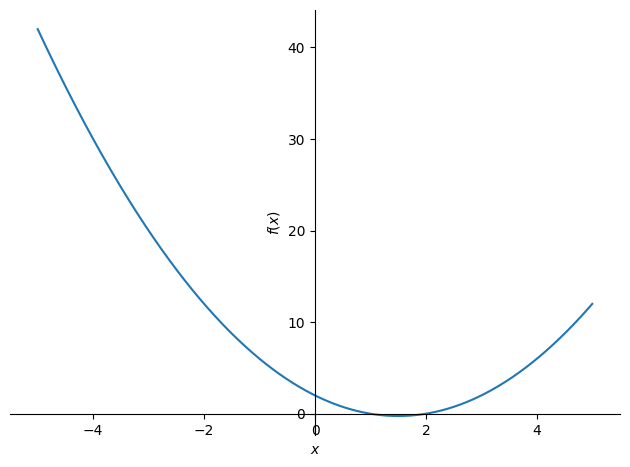

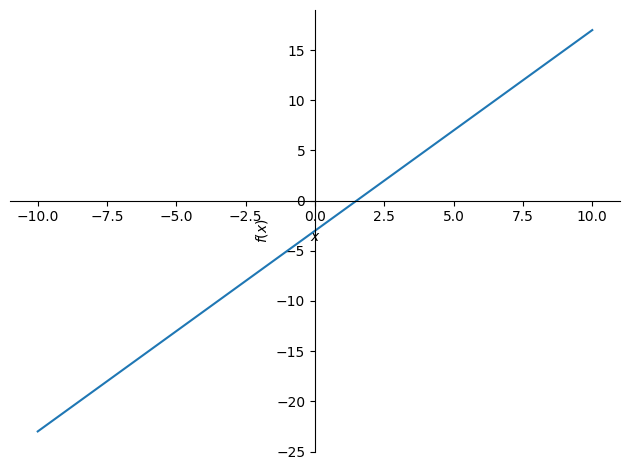

In [ ]:
from sympy.plotting import plot
expr = x**2 - 3*x + 2
plot(expr, (x, -5, 5))
plot(diff(expr, x))


In [ ]:
import numpy as np

def central_difference(f, x, eps=1e-6):
    numerator = f(x + eps) - f(x - eps)
    denominator = 2 * eps
    return numerator / denominator
def target_function(x):
     return x**2
# 설정값
x_point = 5; epsilon = 0.000001

# 실행
result = central_difference(target_function, x_point, epsilon)
print(f"지점 x = {x_point} 에서의 미분값: {result}")
print(f"실제 이론값 (2x): {2 * x_point}")
print(f"오차: {abs(result - 2 * x_point)}")

지점 x = 5 에서의 미분값: 10.00000000139778
실제 이론값 (2x): 10
오차: 1.397779669787269e-09


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 1. 데이터 생성 (시간 t와 위치 s)
# 0초부터 10초까지 0.1초 간격 (총 101개 지점)
t = np.linspace(0, 10, 101)
dt = t[1] - t[0] # 시간 간격 (delta t)
# 위치 함수 s(t) = t^2 (이론적 속도 v(t) = 2t)
s = t**2
velocity = np.gradient(s, dt)
# 3. 결과 확인 (이론값과 비교)
theoretical_v = 2 * t

print(f"시간 5초에서 수치적 속도: {velocity[50]:.2f}")
print(f"시간 5초에서 이론적 속도: {theoretical_v[50]:.2f}")

시간 5초에서 수치적 속도: 10.00
시간 5초에서 이론적 속도: 10.00


In [ ]:
np.gradient(s, dt)

array([ 0.1,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2,  1.4,  1.6,  1.8,  2. ,
        2.2,  2.4,  2.6,  2.8,  3. ,  3.2,  3.4,  3.6,  3.8,  4. ,  4.2,
        4.4,  4.6,  4.8,  5. ,  5.2,  5.4,  5.6,  5.8,  6. ,  6.2,  6.4,
        6.6,  6.8,  7. ,  7.2,  7.4,  7.6,  7.8,  8. ,  8.2,  8.4,  8.6,
        8.8,  9. ,  9.2,  9.4,  9.6,  9.8, 10. , 10.2, 10.4, 10.6, 10.8,
       11. , 11.2, 11.4, 11.6, 11.8, 12. , 12.2, 12.4, 12.6, 12.8, 13. ,
       13.2, 13.4, 13.6, 13.8, 14. , 14.2, 14.4, 14.6, 14.8, 15. , 15.2,
       15.4, 15.6, 15.8, 16. , 16.2, 16.4, 16.6, 16.8, 17. , 17.2, 17.4,
       17.6, 17.8, 18. , 18.2, 18.4, 18.6, 18.8, 19. , 19.2, 19.4, 19.6,
       19.8, 19.9])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 (컬럼명을 A, B로 간소화)
df = pd.read_csv('prices.csv')
df.columns = ['date', 'A', 'B']

# 2. 각 공급업체의 평균 가격 및 공분산 행렬 계산
mean_A = df['A'].mean()
mean_B = df['B'].mean()

cov_matrix = df[['A', 'B']].cov()
var_A = cov_matrix.loc['A', 'A']
var_B = cov_matrix.loc['B', 'B']
cov_AB = cov_matrix.loc['A', 'B'] # 두 업체 간의 공분산

std_A = np.sqrt(var_A)
std_B = np.sqrt(var_B)



In [ ]:
# 3. 이론상 리스크(변동성)를 최소화하는 최적 조달 비율 계산
# 최소분산 가중치 공식: w_A = (var_B - cov_AB) / (var_A + var_B - 2 * cov_AB)
w_A_min_var = (var_B - cov_AB) / (var_A + var_B - 2 * cov_AB)
w_B_min_var = 1 - w_A_min_var

print(f"=== [분산 최소화 최적 조달 결과] ===")
print(f"공급업체 A 조달 비율 (w_A): {w_A_min_var * 100:.2f}%")
print(f"공급업체 B 조달 비율 (w_B): {w_B_min_var * 100:.2f}%")



=== [분산 최소화 최적 조달 결과] ===
공급업체 A 조달 비율 (w_A): 70.23%
공급업체 B 조달 비율 (w_B): 29.77%


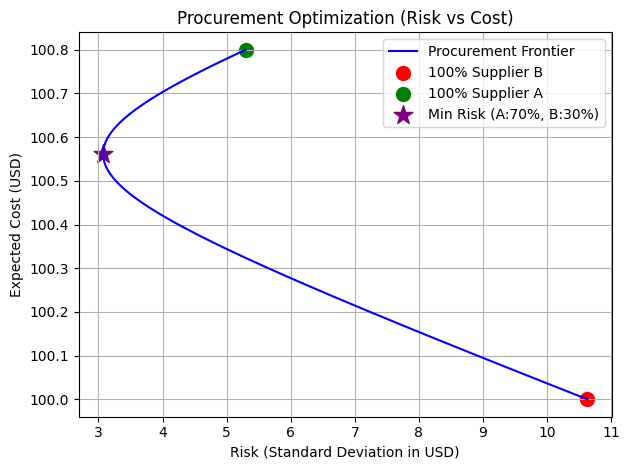

In [ ]:
# 4. 효율적 조달선 (Procurement Frontier) 곡선 시뮬레이션
w_A_range = np.linspace(0, 1, 100)
frontier_cost = []
frontier_risk = []

for w_A in w_A_range:
    w_B = 1 - w_A
    # 포트폴리오 기대 비용 계산
    expected_cost = w_A * mean_A + w_B * mean_B
    # 포트폴리오 리스크(표준편차) 계산
    portfolio_variance = (w_A**2 * var_A) + (w_B**2 * var_B) + (2 * w_A * w_B * cov_AB)
    portfolio_std = np.sqrt(portfolio_variance)

    frontier_cost.append(expected_cost)
    frontier_risk.append(portfolio_std)

# 5. 시각화 그래프 작성 및 이미지 저장
plt.plot(frontier_risk, frontier_cost, 'b-', label='Procurement Frontier')
plt.scatter([std_B], [mean_B], color='red', s=100, label='100% Supplier B')
plt.scatter([std_A], [mean_A], color='green', s=100, label='100% Supplier A')

# 최적의 리스크 최소화 포인트(별 모양) 표시
min_var_risk = np.sqrt((w_A_min_var**2 * var_A) + (w_B_min_var**2 * var_B) + (2 * w_A_min_var * w_B_min_var * cov_AB))
min_var_cost = w_A_min_var * mean_A + w_B_min_var * mean_B
plt.scatter([min_var_risk], [min_var_cost], color='purple', marker='*', s=200, label=f'Min Risk (A:{w_A_min_var*100:.0f}%, B:{w_B_min_var*100:.0f}%)')

plt.title('Procurement Optimization (Risk vs Cost)')
plt.xlabel('Risk (Standard Deviation in USD)')
plt.ylabel('Expected Cost (USD)')
plt.grid(True)
plt.legend()
plt.tight_layout()

# 그래프를 파일로 저장
plt.savefig('procurement_frontier_plot.png')